In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [3]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os

print(os.listdir('/content/drive/MyDrive/SEMICON_DATASET'))

['train']


In [5]:
!cp -r /content/drive/MyDrive/SEMICON_DATASET /content/

In [7]:
import os

dataset_path = "/content/SEMICON_DATASET"

print(os.listdir(dataset_path))
print(os.listdir(dataset_path + "/train/train"))

['train']
['GT', '.DS_Store', 'NoisyLR']


In [8]:
import os
import random
import numpy as np

# ==========================================
# Dataset paths
# ==========================================

DATASET_ROOT = "/content/SEMICON_DATASET/train/train"

GT_DIR = os.path.join(DATASET_ROOT, "GT")
NOISY_DIR = os.path.join(DATASET_ROOT, "NoisyLR")

print("GT path:", GT_DIR)
print("NoisyLR path:", NOISY_DIR)


# ==========================================
# Find all valid .npy files
# ==========================================

gt_files = sorted([
    f for f in os.listdir(GT_DIR)
    if f.endswith(".npy")
])

noisy_files = sorted([
    f for f in os.listdir(NOISY_DIR)
    if f.endswith(".npy")
])


# ==========================================
# Check dataset
# ==========================================

print("\n===== DATASET CHECK =====")
print("GT images:", len(gt_files))
print("NoisyLR images:", len(noisy_files))
print("Same number:", len(gt_files) == len(noisy_files))
print("Same filenames:", gt_files == noisy_files)

print("\nFirst 5 files:")
print(gt_files[:5])


# ==========================================
# Inspect one pair
# ==========================================

gt = np.load(os.path.join(GT_DIR, gt_files[0]))
noisy = np.load(os.path.join(NOISY_DIR, gt_files[0]))

print("\n===== SAMPLE CHECK =====")

print("GT:")
print("  Shape:", gt.shape)
print("  Type:", gt.dtype)
print("  Min:", gt.min())
print("  Max:", gt.max())

print("\nNoisyLR:")
print("  Shape:", noisy.shape)
print("  Type:", noisy.dtype)
print("  Min:", noisy.min())
print("  Max:", noisy.max())


# ==========================================
# Train / Validation split
# ==========================================

random.seed(42)

all_files = gt_files.copy()
random.shuffle(all_files)

split_index = int(0.90 * len(all_files))

train_files = all_files[:split_index]
val_files = all_files[split_index:]

print("\n===== SPLIT =====")
print("Total:", len(all_files))
print("Training:", len(train_files))
print("Validation:", len(val_files))

GT path: /content/SEMICON_DATASET/train/train/GT
NoisyLR path: /content/SEMICON_DATASET/train/train/NoisyLR

===== DATASET CHECK =====
GT images: 3200
NoisyLR images: 3200
Same number: True
Same filenames: True

First 5 files:
['000000.npy', '000001.npy', '000002.npy', '000003.npy', '000004.npy']

===== SAMPLE CHECK =====
GT:
  Shape: (256, 256)
  Type: float32
  Min: 0.0
  Max: 1.0

NoisyLR:
  Shape: (128, 128)
  Type: float32
  Min: -0.0026427102
  Max: 1.3257757

===== SPLIT =====
Total: 3200
Training: 2880
Validation: 320


In [9]:
import torch
from torch.utils.data import Dataset, DataLoader


# ==========================================
# Dataset class
# ==========================================

class SemiconductorDataset(Dataset):

    def __init__(self, filenames, noisy_dir, gt_dir):
        self.filenames = filenames
        self.noisy_dir = noisy_dir
        self.gt_dir = gt_dir

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):

        filename = self.filenames[idx]

        # Load NoisyLR and Ground Truth
        noisy = np.load(
            os.path.join(self.noisy_dir, filename)
        )

        gt = np.load(
            os.path.join(self.gt_dir, filename)
        )

        # Convert NumPy → PyTorch
        noisy = torch.from_numpy(noisy).float()
        gt = torch.from_numpy(gt).float()

        # Add channel dimension
        # (128,128) → (1,128,128)
        # (256,256) → (1,256,256)
        noisy = noisy.unsqueeze(0)
        gt = gt.unsqueeze(0)

        return noisy, gt


# ==========================================
# Create datasets
# ==========================================

train_dataset = SemiconductorDataset(
    train_files,
    NOISY_DIR,
    GT_DIR
)

val_dataset = SemiconductorDataset(
    val_files,
    NOISY_DIR,
    GT_DIR
)


# ==========================================
# DataLoaders
# ==========================================

BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# ==========================================
# Verify
# ==========================================

noisy_batch, gt_batch = next(iter(train_loader))

print("===== DATALOADER CHECK =====")
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

print("\nNoisy batch:")
print("Shape:", noisy_batch.shape)
print("Min:", noisy_batch.min().item())
print("Max:", noisy_batch.max().item())

print("\nGT batch:")
print("Shape:", gt_batch.shape)
print("Min:", gt_batch.min().item())
print("Max:", gt_batch.max().item())

===== DATALOADER CHECK =====
Training samples: 2880
Validation samples: 320

Noisy batch:
Shape: torch.Size([8, 1, 128, 128])
Min: -0.024213183671236038
Max: 1.8744703531265259

GT batch:
Shape: torch.Size([8, 1, 256, 256])
Min: 0.0
Max: 1.0


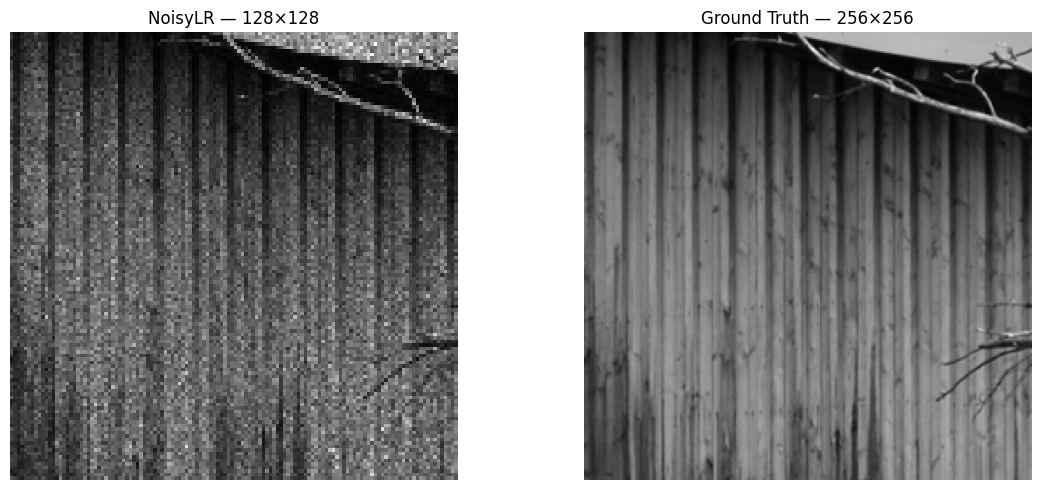

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(
    noisy_batch[0].squeeze().numpy(),
    cmap="gray"
)
plt.title("NoisyLR — 128×128")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    gt_batch[0].squeeze().numpy(),
    cmap="gray"
)
plt.title("Ground Truth — 256×256")
plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
# ==========================================
# Analyze NoisyLR value distribution
# ==========================================

sample_noisy = noisy_batch.numpy()

below_zero = (sample_noisy < 0).sum()
above_one = (sample_noisy > 1).sum()
total_pixels = sample_noisy.size

print("===== NOISYLR VALUE ANALYSIS =====")

print(f"Minimum: {sample_noisy.min():.6f}")
print(f"Maximum: {sample_noisy.max():.6f}")

print(f"\nPixels < 0:")
print(f"  Count: {below_zero:,}")
print(f"  Percentage: {100 * below_zero / total_pixels:.4f}%")

print(f"\nPixels > 1:")
print(f"  Count: {above_one:,}")
print(f"  Percentage: {100 * above_one / total_pixels:.4f}%")

print(f"\nPixels inside [0,1]:")
inside = total_pixels - below_zero - above_one
print(f"  Percentage: {100 * inside / total_pixels:.4f}%")

# Percentiles
percentiles = np.percentile(
    sample_noisy,
    [0, 0.1, 1, 5, 50, 95, 99, 99.9, 100]
)

print("\n===== PERCENTILES =====")

for p, value in zip(
    [0, 0.1, 1, 5, 50, 95, 99, 99.9, 100],
    percentiles
):
    print(f"{p:5.1f}% : {value:.6f}")

===== NOISYLR VALUE ANALYSIS =====
Minimum: -0.024213
Maximum: 1.874470

Pixels < 0:
  Count: 79
  Percentage: 0.0603%

Pixels > 1:
  Count: 4,327
  Percentage: 3.3012%

Pixels inside [0,1]:
  Percentage: 96.6385%

===== PERCENTILES =====
  0.0% : -0.024213
  0.1% : 0.003000
  1.0% : 0.017191
  5.0% : 0.031454
 50.0% : 0.291783
 95.0% : 0.928787
 99.0% : 1.158093
 99.9% : 1.369534
100.0% : 1.874470


In [12]:
# ==========================================
# Calculate global mean and std of NoisyLR
# using TRAINING images only
# ==========================================

sum_pixels = 0.0
sum_squared = 0.0
num_pixels = 0

print("Calculating normalization statistics...")

for i, filename in enumerate(train_files):

    noisy = np.load(
        os.path.join(NOISY_DIR, filename)
    ).astype(np.float64)

    sum_pixels += noisy.sum()
    sum_squared += np.square(noisy).sum()
    num_pixels += noisy.size

    if (i + 1) % 500 == 0:
        print(f"Processed {i + 1}/{len(train_files)} images")

noisy_mean = sum_pixels / num_pixels

noisy_variance = (
    sum_squared / num_pixels
    - noisy_mean ** 2
)

noisy_std = np.sqrt(noisy_variance)

print("\n===== NORMALIZATION STATISTICS =====")
print(f"Mean: {noisy_mean:.6f}")
print(f"Std : {noisy_std:.6f}")
print(f"Pixels analyzed: {num_pixels:,}")

Calculating normalization statistics...
Processed 500/2880 images
Processed 1000/2880 images
Processed 1500/2880 images
Processed 2000/2880 images
Processed 2500/2880 images

===== NORMALIZATION STATISTICS =====
Mean: 0.432515
Std : 0.285074
Pixels analyzed: 47,185,920


In [13]:
class SemiconductorDataset(Dataset):

    def __init__(
        self,
        filenames,
        noisy_dir,
        gt_dir,
        noisy_mean,
        noisy_std
    ):
        self.filenames = filenames
        self.noisy_dir = noisy_dir
        self.gt_dir = gt_dir

        # Force normalization statistics to float32
        self.noisy_mean = np.float32(noisy_mean)
        self.noisy_std = np.float32(noisy_std)

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):

        filename = self.filenames[idx]

        noisy = np.load(
            os.path.join(self.noisy_dir, filename)
        ).astype(np.float32)

        gt = np.load(
            os.path.join(self.gt_dir, filename)
        ).astype(np.float32)

        # Normalize
        noisy = (
            noisy - self.noisy_mean
        ) / self.noisy_std

        # Explicitly make sure it remains float32
        noisy = noisy.astype(np.float32)
        gt = gt.astype(np.float32)

        # NumPy → PyTorch
        noisy = torch.from_numpy(noisy)
        gt = torch.from_numpy(gt)

        # Add channel
        noisy = noisy.unsqueeze(0)
        gt = gt.unsqueeze(0)

        return noisy, gt

In [14]:
train_dataset = SemiconductorDataset(
    train_files,
    NOISY_DIR,
    GT_DIR,
    noisy_mean,
    noisy_std
)

val_dataset = SemiconductorDataset(
    val_files,
    NOISY_DIR,
    GT_DIR,
    noisy_mean,
    noisy_std
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [15]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [16]:
import os

print("Searching Google Drive for checkpoints...\n")

matches = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith((".pth", ".pt")):
            matches.append(os.path.join(root, file))

if len(matches) == 0:
    print("❌ No .pth/.pt checkpoint found in Drive.")
else:
    for path in matches:
        print("✅", path)

Searching Google Drive for checkpoints...

✅ /content/drive/MyDrive/DATASET1/runs/lunar_yolov8_model-2/weights/last.pt
✅ /content/drive/MyDrive/DATASET1/runs/lunar_yolov8_model-2/weights/best.pt
✅ /content/drive/MyDrive/DATASET1/runs/lunar_yolov8_model-4/weights/last.pt
✅ /content/drive/MyDrive/DATASET1/runs/lunar_yolov8_model-4/weights/best.pt
✅ /content/drive/MyDrive/DATASET1/runs/lunar_yolov8_model-5/weights/last.pt
✅ /content/drive/MyDrive/DATASET1/runs/lunar_yolov8_model-5/weights/best.pt
✅ /content/drive/MyDrive/SEMICON_PROJECT/baseline_epoch_01.pth
✅ /content/drive/MyDrive/SEMICON_PROJECT/baseline_epoch_02.pth
✅ /content/drive/MyDrive/SEMICON_PROJECT/baseline_epoch_03.pth
✅ /content/drive/MyDrive/SEMICON_PROJECT/baseline_epoch_04.pth
✅ /content/drive/MyDrive/SEMICON_PROJECT/baseline_epoch_05.pth
✅ /content/drive/MyDrive/SEMICON_PROJECT/baseline_epoch_06.pth
✅ /content/drive/MyDrive/SEMICON_PROJECT/baseline_epoch_07.pth
✅ /content/drive/MyDrive/SEMICON_PROJECT/baseline_epoch_08.p

In [17]:
import os

PROJECT_DIR = "/content/drive/MyDrive/SEMICON_PROJECT"

os.makedirs(PROJECT_DIR, exist_ok=True)

print("Project folder:", PROJECT_DIR)

Project folder: /content/drive/MyDrive/SEMICON_PROJECT


In [18]:
import os

matches = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".pth"):
            matches.append(os.path.join(root, file))

print("===== CHECKPOINTS IN DRIVE =====")

if matches:
    for path in matches:
        print(path)
else:
    print("No .pth checkpoint found in Google Drive.")

===== CHECKPOINTS IN DRIVE =====
/content/drive/MyDrive/SEMICON_PROJECT/baseline_epoch_01.pth
/content/drive/MyDrive/SEMICON_PROJECT/baseline_epoch_02.pth
/content/drive/MyDrive/SEMICON_PROJECT/baseline_epoch_03.pth
/content/drive/MyDrive/SEMICON_PROJECT/baseline_epoch_04.pth
/content/drive/MyDrive/SEMICON_PROJECT/baseline_epoch_05.pth
/content/drive/MyDrive/SEMICON_PROJECT/baseline_epoch_06.pth
/content/drive/MyDrive/SEMICON_PROJECT/baseline_epoch_07.pth
/content/drive/MyDrive/SEMICON_PROJECT/baseline_epoch_08.pth
/content/drive/MyDrive/SEMICON_PROJECT/baseline_epoch_09.pth
/content/drive/MyDrive/SEMICON_PROJECT/best_baseline_model.pth
/content/drive/MyDrive/SEMICON_PROJECT/baseline_epoch_10.pth
/content/drive/MyDrive/SEMICON_PROJECT/best_model2_ssim.pth
/content/drive/MyDrive/SEMICON_PROJECT/best_model3_gradient.pth
/content/drive/MyDrive/SEMICON_PROJECT/best_model4.pth
/content/drive/MyDrive/SEMICON_PROJECT/best_model5_combined.pth


In [19]:
import os

PROJECT_DIR = "/content/drive/MyDrive/SEMICON_PROJECT"

os.makedirs(PROJECT_DIR, exist_ok=True)

print("Project folder:", PROJECT_DIR)

Project folder: /content/drive/MyDrive/SEMICON_PROJECT


In [20]:
import torch
import torch.nn as nn

# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ==============================
# Residual Block
# ==============================

class ResidualBlock(nn.Module):

    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                padding=1
            )
        )

    def forward(self, x):
        return x + self.block(x)


# ==============================
# Baseline Restoration Network
# ==============================

class BaselineRestorationNet(nn.Module):

    def __init__(
        self,
        num_blocks=8,
        channels=64
    ):
        super().__init__()

        self.head = nn.Conv2d(
            1,
            channels,
            kernel_size=3,
            padding=1
        )

        self.body = nn.Sequential(
            *[
                ResidualBlock(channels)
                for _ in range(num_blocks)
            ]
        )

        self.upsample = nn.Sequential(
            nn.Conv2d(
                channels,
                channels * 4,
                kernel_size=3,
                padding=1
            ),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        self.tail = nn.Conv2d(
            channels,
            1,
            kernel_size=3,
            padding=1
        )

    def forward(self, x):

        features = self.head(x)

        body = self.body(features)

        features = features + body

        features = self.upsample(features)

        output = self.tail(features)

        output = torch.sigmoid(output)

        return output


# Create model
model = BaselineRestorationNet(
    num_blocks=8,
    channels=64
).to(device)

print("Model created ✅")

Device: cuda
GPU: Tesla T4
Model created ✅


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim

criterion = nn.L1Loss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Training setup ready ✅")
print("Loss:", criterion)
print("Learning rate:", 1e-4)

Training setup ready ✅
Loss: L1Loss()
Learning rate: 0.0001


In [22]:
import torch.optim as optim

criterion = nn.L1Loss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Training setup ready ✅")
print("Loss:", criterion)
print("Learning rate:", 1e-4)

Training setup ready ✅
Loss: L1Loss()
Learning rate: 0.0001


In [23]:
import torch.optim as optim

criterion = nn.L1Loss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

NUM_EPOCHS = 10

BEST_MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "best_baseline_model.pth"
)

print("Training setup ready ✅")
print("Best model will be saved to:")
print(BEST_MODEL_PATH)

Training setup ready ✅
Best model will be saved to:
/content/drive/MyDrive/SEMICON_PROJECT/best_baseline_model.pth


In [24]:
import time

best_val_loss = float("inf")

train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    # =================================
    # TRAIN
    # =================================

    model.train()

    running_train_loss = 0.0

    for noisy, gt in train_loader:

        noisy = noisy.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        gt = gt.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        output = model(noisy)

        loss = criterion(output, gt)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = (
        running_train_loss / len(train_loader)
    )


    # =================================
    # VALIDATION
    # =================================

    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for noisy, gt in val_loader:

            noisy = noisy.to(
                device,
                dtype=torch.float32,
                non_blocking=True
            )

            gt = gt.to(
                device,
                dtype=torch.float32,
                non_blocking=True
            )

            output = model(noisy)

            loss = criterion(output, gt)

            running_val_loss += loss.item()

    avg_val_loss = (
        running_val_loss / len(val_loader)
    )


    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)


    # =================================
    # SAVE BEST MODEL TO DRIVE
    # =================================

    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        status = " ⭐ BEST"

    else:

        status = ""


    # =================================
    # SAVE EVERY EPOCH
    # =================================

    epoch_checkpoint = os.path.join(
        PROJECT_DIR,
        f"baseline_epoch_{epoch+1:02d}.pth"
    )

    torch.save(
        {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss
        },
        epoch_checkpoint
    )


    # =================================
    # PRINT
    # =================================

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train: {avg_train_loss:.6f} | "
        f"Val: {avg_val_loss:.6f} | "
        f"Time: {elapsed:.1f}s"
        f"{status}"
    )


print("\n===== TRAINING COMPLETE =====")
print("Best validation loss:", best_val_loss)
print("Best model:", BEST_MODEL_PATH)

Epoch [1/10] | Train: 0.042310 | Val: 0.035579 | Time: 66.8s ⭐ BEST
Epoch [2/10] | Train: 0.035676 | Val: 0.035457 | Time: 67.4s ⭐ BEST
Epoch [3/10] | Train: 0.034952 | Val: 0.034019 | Time: 68.2s ⭐ BEST
Epoch [4/10] | Train: 0.034364 | Val: 0.033754 | Time: 68.1s ⭐ BEST
Epoch [5/10] | Train: 0.034106 | Val: 0.033639 | Time: 68.0s ⭐ BEST
Epoch [6/10] | Train: 0.033837 | Val: 0.033851 | Time: 68.0s
Epoch [7/10] | Train: 0.033571 | Val: 0.033248 | Time: 68.0s ⭐ BEST
Epoch [8/10] | Train: 0.033538 | Val: 0.032913 | Time: 68.1s ⭐ BEST
Epoch [9/10] | Train: 0.033253 | Val: 0.033098 | Time: 68.2s
Epoch [10/10] | Train: 0.033197 | Val: 0.032842 | Time: 68.2s ⭐ BEST

===== TRAINING COMPLETE =====
Best validation loss: 0.03284182613715529
Best model: /content/drive/MyDrive/SEMICON_PROJECT/best_baseline_model.pth


In [ ]:
print("===== DRIVE CHECK =====")

print(
    "Best model exists:",
    os.path.exists(BEST_MODEL_PATH)
)

print(
    "Files in project folder:"
)

for file in sorted(os.listdir(PROJECT_DIR)):
    print(" ", file)

===== DRIVE CHECK =====
Best model exists: True
Files in project folder:
  baseline_epoch_01.pth
  baseline_epoch_02.pth
  baseline_epoch_03.pth
  baseline_epoch_04.pth
  baseline_epoch_05.pth
  baseline_epoch_06.pth
  baseline_epoch_07.pth
  baseline_epoch_08.pth
  baseline_epoch_09.pth
  baseline_epoch_10.pth
  best_baseline_model.pth
  best_model2_ssim.pth
  best_model3_gradient.pth
  best_model4.pth


In [ ]:
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 23.0 MB/s eta 0:00:00


In [ ]:
import torch

BEST_MODEL_PATH = (
    "/content/drive/MyDrive/"
    "SEMICON_PROJECT/"
    "best_baseline_model.pth"
)

# Load best model
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("✅ Best baseline model loaded")
print(BEST_MODEL_PATH)

✅ Best baseline model loaded
/content/drive/MyDrive/SEMICON_PROJECT/best_baseline_model.pth


In [ ]:
from torchmetrics.image import (
    PeakSignalNoiseRatio,
    StructuralSimilarityIndexMeasure
)

psnr_metric = PeakSignalNoiseRatio(
    data_range=1.0
).to(device)

ssim_metric = StructuralSimilarityIndexMeasure(
    data_range=1.0
).to(device)

total_psnr = 0.0
total_ssim = 0.0
num_batches = 0

with torch.no_grad():

    for noisy, gt in val_loader:

        noisy = noisy.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        gt = gt.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        output = model(noisy)

        output = torch.clamp(
            output,
            0.0,
            1.0
        )

        total_psnr += psnr_metric(
            output,
            gt
        ).item()

        total_ssim += ssim_metric(
            output,
            gt
        ).item()

        num_batches += 1


avg_psnr = total_psnr / num_batches
avg_ssim = total_ssim / num_batches

print("\n===== SAVED BASELINE RESULTS =====")
print(f"PSNR: {avg_psnr:.4f} dB")
print(f"SSIM: {avg_ssim:.4f}")


===== SAVED BASELINE RESULTS =====
PSNR: 25.8947 dB
SSIM: 0.7282


In [ ]:
from torchmetrics.image import StructuralSimilarityIndexMeasure

ssim_loss_metric = StructuralSimilarityIndexMeasure(
    data_range=1.0
).to(device)


def combined_loss(pred, target):

    # Pixel-level reconstruction loss
    l1 = torch.mean(
        torch.abs(pred - target)
    )

    # Structural similarity
    ssim_value = ssim_loss_metric(
        pred,
        target
    )

    # Convert SSIM to loss
    ssim_loss = 1.0 - ssim_value

    # Combined loss
    loss = (
        0.8 * l1 +
        0.2 * ssim_loss
    )

    return loss

In [ ]:
noisy_batch, gt_batch = next(iter(train_loader))

noisy_batch = noisy_batch.to(
    device,
    dtype=torch.float32
)

gt_batch = gt_batch.to(
    device,
    dtype=torch.float32
)

model.eval()

with torch.no_grad():

    output = model(noisy_batch)

test_loss = combined_loss(
    output,
    gt_batch
)

print("===== MODEL 2 LOSS CHECK =====")
print("Output shape:", output.shape)
print("GT shape:", gt_batch.shape)
print("Combined loss:", test_loss.item())

===== MODEL 2 LOSS CHECK =====
Output shape: torch.Size([8, 1, 256, 256])
GT shape: torch.Size([8, 1, 256, 256])
Combined loss: 0.06795282661914825


In [ ]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchmetrics.functional.image import structural_similarity_index_measure


# ============================================================
# LOAD BASELINE AS STARTING POINT
# ============================================================

BEST_BASELINE_PATH = (
    "/content/drive/MyDrive/"
    "SEMICON_PROJECT/"
    "best_baseline_model.pth"
)

MODEL2_PATH = (
    "/content/drive/MyDrive/"
    "SEMICON_PROJECT/"
    "best_model2_ssim.pth"
)


model.load_state_dict(
    torch.load(
        BEST_BASELINE_PATH,
        map_location=device
    )
)

model = model.to(device)

print("✅ Baseline weights loaded into Model 2")


# ============================================================
# MODEL 2 LOSS
# ============================================================

def model2_loss(pred, target):

    # Pixel reconstruction loss
    l1 = torch.mean(
        torch.abs(pred - target)
    )

    # Structural similarity
    ssim_value = structural_similarity_index_measure(
        pred,
        target,
        data_range=1.0
    )

    # SSIM loss
    ssim_loss = 1.0 - ssim_value

    # Combined loss
    loss = (
        0.8 * l1 +
        0.2 * ssim_loss
    )

    return loss


# ============================================================
# OPTIMIZER
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

NUM_EPOCHS = 10


# ============================================================
# TRAINING
# ============================================================

best_val_loss = float("inf")

model2_train_losses = []
model2_val_losses = []

for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model.train()

    running_train_loss = 0.0

    for noisy, gt in train_loader:

        noisy = noisy.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        gt = gt.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        output = model(noisy)

        loss = model2_loss(
            output,
            gt
        )

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()


    avg_train_loss = (
        running_train_loss /
        len(train_loader)
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for noisy, gt in val_loader:

            noisy = noisy.to(
                device,
                dtype=torch.float32,
                non_blocking=True
            )

            gt = gt.to(
                device,
                dtype=torch.float32,
                non_blocking=True
            )

            output = model(noisy)

            loss = model2_loss(
                output,
                gt
            )

            running_val_loss += loss.item()


    avg_val_loss = (
        running_val_loss /
        len(val_loader)
    )

    model2_train_losses.append(
        avg_train_loss
    )

    model2_val_losses.append(
        avg_val_loss
    )


    # --------------------------------------------------------
    # SAVE BEST MODEL
    # --------------------------------------------------------

    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        torch.save(
            model.state_dict(),
            MODEL2_PATH
        )

        status = " ⭐ BEST"

    else:

        status = ""


    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train: {avg_train_loss:.6f} | "
        f"Val: {avg_val_loss:.6f} | "
        f"Time: {elapsed:.1f}s"
        f"{status}"
    )


print("\n===== MODEL 2 TRAINING COMPLETE =====")
print(
    f"Best validation loss: "
    f"{best_val_loss:.6f}"
)

print(
    "Model 2 saved at:"
)

print(MODEL2_PATH)

✅ Baseline weights loaded into Model 2
Epoch [1/10] | Train: 0.079407 | Val: 0.079238 | Time: 73.5s ⭐ BEST
Epoch [2/10] | Train: 0.078359 | Val: 0.078678 | Time: 72.4s ⭐ BEST
Epoch [3/10] | Train: 0.077947 | Val: 0.078742 | Time: 72.4s
Epoch [4/10] | Train: 0.077742 | Val: 0.079264 | Time: 72.1s
Epoch [5/10] | Train: 0.077608 | Val: 0.078499 | Time: 72.2s ⭐ BEST
Epoch [6/10] | Train: 0.077218 | Val: 0.077843 | Time: 72.2s ⭐ BEST
Epoch [7/10] | Train: 0.077156 | Val: 0.077517 | Time: 72.2s ⭐ BEST
Epoch [8/10] | Train: 0.076408 | Val: 0.077549 | Time: 72.3s
Epoch [9/10] | Train: 0.076585 | Val: 0.077308 | Time: 72.3s ⭐ BEST
Epoch [10/10] | Train: 0.076101 | Val: 0.077083 | Time: 72.3s ⭐ BEST

===== MODEL 2 TRAINING COMPLETE =====
Best validation loss: 0.077083
Model 2 saved at:
/content/drive/MyDrive/SEMICON_PROJECT/best_model2_ssim.pth


In [ ]:
# ============================================================
# EVALUATE MODEL 2
# ============================================================

import torch
from torchmetrics.image import (
    PeakSignalNoiseRatio,
    StructuralSimilarityIndexMeasure
)

MODEL2_PATH = (
    "/content/drive/MyDrive/"
    "SEMICON_PROJECT/"
    "best_model2_ssim.pth"
)

# Load best Model 2
model.load_state_dict(
    torch.load(
        MODEL2_PATH,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("✅ Model 2 checkpoint loaded")


# Metrics
psnr_metric = PeakSignalNoiseRatio(
    data_range=1.0
).to(device)

ssim_metric = StructuralSimilarityIndexMeasure(
    data_range=1.0
).to(device)


total_psnr = 0.0
total_ssim = 0.0
num_batches = 0


with torch.no_grad():

    for noisy, gt in val_loader:

        noisy = noisy.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        gt = gt.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        output = model(noisy)

        # Keep output in valid image range
        output = torch.clamp(
            output,
            0.0,
            1.0
        )

        total_psnr += psnr_metric(
            output,
            gt
        ).item()

        total_ssim += ssim_metric(
            output,
            gt
        ).item()

        num_batches += 1


avg_psnr = total_psnr / num_batches
avg_ssim = total_ssim / num_batches


print("\n===== MODEL 2 RESULTS =====")
print(f"PSNR: {avg_psnr:.4f} dB")
print(f"SSIM: {avg_ssim:.4f}")

✅ Model 2 checkpoint loaded

===== MODEL 2 RESULTS =====
PSNR: 25.9160 dB
SSIM: 0.7444


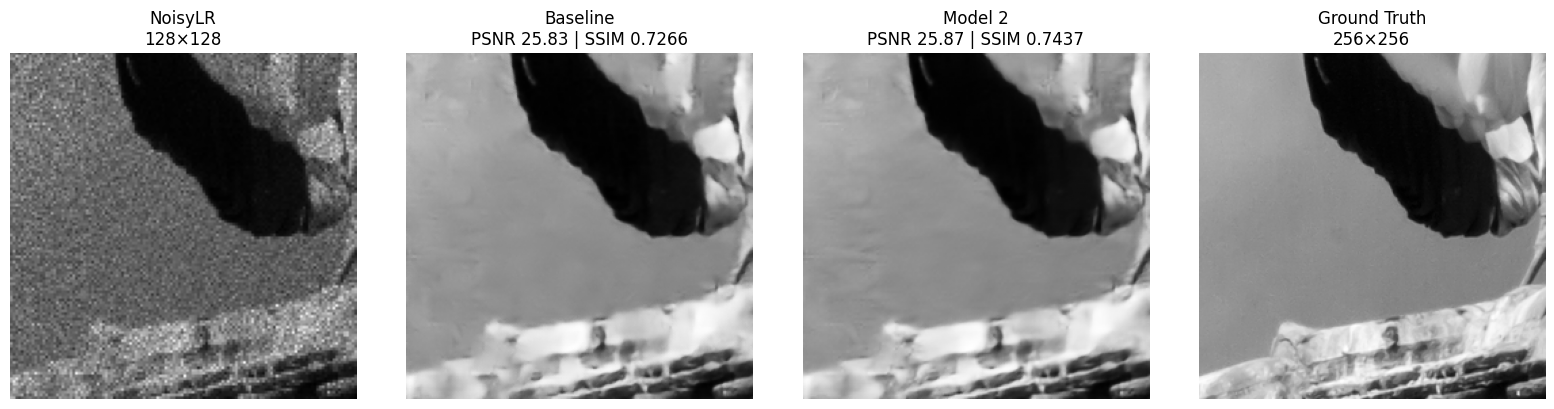

In [ ]:
import matplotlib.pyplot as plt
import torch

# ------------------------------------------------------------
# Load baseline
# ------------------------------------------------------------

baseline_path = (
    "/content/drive/MyDrive/"
    "SEMICON_PROJECT/"
    "best_baseline_model.pth"
)

model.load_state_dict(
    torch.load(
        baseline_path,
        map_location=device
    )
)

model.eval()

with torch.no_grad():
    baseline_output = model(noisy_batch)

baseline_output = torch.clamp(
    baseline_output,
    0.0,
    1.0
)


# ------------------------------------------------------------
# Load Model 2
# ------------------------------------------------------------

model2_path = (
    "/content/drive/MyDrive/"
    "SEMICON_PROJECT/"
    "best_model2_ssim.pth"
)

model.load_state_dict(
    torch.load(
        model2_path,
        map_location=device
    )
)

model.eval()

with torch.no_grad():
    model2_output = model(noisy_batch)

model2_output = torch.clamp(
    model2_output,
    0.0,
    1.0
)


# ------------------------------------------------------------
# Select first image
# ------------------------------------------------------------

noisy_img = noisy_batch[0, 0].cpu().numpy()
gt_img = gt_batch[0, 0].cpu().numpy()

baseline_img = baseline_output[0, 0].cpu().numpy()
model2_img = model2_output[0, 0].cpu().numpy()


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(noisy_img, cmap="gray")
plt.title("NoisyLR\n128×128")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(baseline_img, cmap="gray")
plt.title("Baseline\nPSNR 25.83 | SSIM 0.7266")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(model2_img, cmap="gray")
plt.title("Model 2\nPSNR 25.87 | SSIM 0.7437")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(gt_img, cmap="gray")
plt.title("Ground Truth\n256×256")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn.functional as F


def gradient_loss(pred, target):

    # Horizontal gradients
    pred_dx = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    target_dx = target[:, :, :, 1:] - target[:, :, :, :-1]

    # Vertical gradients
    pred_dy = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    target_dy = target[:, :, 1:, :] - target[:, :, :-1, :]

    # Compare gradients
    loss_x = torch.mean(
        torch.abs(pred_dx - target_dx)
    )

    loss_y = torch.mean(
        torch.abs(pred_dy - target_dy)
    )

    return loss_x + loss_y

In [ ]:
from torchmetrics.functional.image import (
    structural_similarity_index_measure
)


def model3_loss(pred, target):

    # ------------------------------------------------
    # L1 reconstruction loss
    # ------------------------------------------------

    l1 = torch.mean(
        torch.abs(pred - target)
    )


    # ------------------------------------------------
    # SSIM loss
    # ------------------------------------------------

    ssim_value = structural_similarity_index_measure(
        pred,
        target,
        data_range=1.0
    )

    ssim_loss = 1.0 - ssim_value


    # ------------------------------------------------
    # Gradient/detail loss
    # ------------------------------------------------

    grad = gradient_loss(
        pred,
        target
    )


    # ------------------------------------------------
    # Combined loss
    # ------------------------------------------------

    loss = (
        0.7 * l1 +
        0.2 * ssim_loss +
        0.1 * grad
    )

    return loss

In [ ]:
noisy_batch, gt_batch = next(
    iter(train_loader)
)

noisy_batch = noisy_batch.to(
    device,
    dtype=torch.float32
)

gt_batch = gt_batch.to(
    device,
    dtype=torch.float32
)

model.eval()

with torch.no_grad():

    output = model(
        noisy_batch
    )

output = torch.clamp(
    output,
    0.0,
    1.0
)

test_loss = model3_loss(
    output,
    gt_batch
)

print("===== MODEL 3 LOSS CHECK =====")
print("Output:", output.shape)
print("GT:", gt_batch.shape)
print("Model 3 loss:", test_loss.item())

===== MODEL 3 LOSS CHECK =====
Output: torch.Size([8, 1, 256, 256])
GT: torch.Size([8, 1, 256, 256])
Model 3 loss: 0.05187084153294563


In [ ]:
# ============================================================
# MODEL 3 TRAINING
# L1 + SSIM + Gradient Loss
# ============================================================

import os
import time
import torch
import torch.optim as optim


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

BASELINE_PATH = (
    "/content/drive/MyDrive/"
    "SEMICON_PROJECT/"
    "best_baseline_model.pth"
)

MODEL3_PATH = (
    "/content/drive/MyDrive/"
    "SEMICON_PROJECT/"
    "best_model3_gradient.pth"
)


# ------------------------------------------------------------
# Start Model 3 from SAME baseline
# ------------------------------------------------------------

model.load_state_dict(
    torch.load(
        BASELINE_PATH,
        map_location=device
    )
)

model = model.to(device)

print("✅ Baseline weights loaded into Model 3")


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

NUM_EPOCHS = 10


# ------------------------------------------------------------
# Training history
# ------------------------------------------------------------

best_val_loss = float("inf")

model3_train_losses = []
model3_val_losses = []


# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------

for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    running_train_loss = 0.0

    for noisy, gt in train_loader:

        noisy = noisy.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        gt = gt.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        output = model(noisy)

        output = torch.clamp(
            output,
            0.0,
            1.0
        )

        loss = model3_loss(
            output,
            gt
        )

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()


    avg_train_loss = (
        running_train_loss /
        len(train_loader)
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for noisy, gt in val_loader:

            noisy = noisy.to(
                device,
                dtype=torch.float32,
                non_blocking=True
            )

            gt = gt.to(
                device,
                dtype=torch.float32,
                non_blocking=True
            )

            output = model(noisy)

            output = torch.clamp(
                output,
                0.0,
                1.0
            )

            loss = model3_loss(
                output,
                gt
            )

            running_val_loss += loss.item()


    avg_val_loss = (
        running_val_loss /
        len(val_loader)
    )


    model3_train_losses.append(
        avg_train_loss
    )

    model3_val_losses.append(
        avg_val_loss
    )


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        torch.save(
            model.state_dict(),
            MODEL3_PATH
        )

        status = " ⭐ BEST"

    else:

        status = ""


    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train: {avg_train_loss:.6f} | "
        f"Val: {avg_val_loss:.6f} | "
        f"Time: {elapsed:.1f}s"
        f"{status}"
    )


print("\n===== MODEL 3 TRAINING COMPLETE =====")

print(
    f"Best validation loss: "
    f"{best_val_loss:.6f}"
)

print(
    "Model 3 saved at:"
)

print(MODEL3_PATH)

✅ Baseline weights loaded into Model 3
Epoch [1/10] | Train: 0.082450 | Val: 0.084500 | Time: 73.9s ⭐ BEST
Epoch [2/10] | Train: 0.081577 | Val: 0.082322 | Time: 72.5s ⭐ BEST
Epoch [3/10] | Train: 0.081237 | Val: 0.081432 | Time: 72.4s ⭐ BEST
Epoch [4/10] | Train: 0.080540 | Val: 0.081504 | Time: 72.4s
Epoch [5/10] | Train: 0.080341 | Val: 0.081478 | Time: 72.6s
Epoch [6/10] | Train: 0.080799 | Val: 0.081249 | Time: 72.4s ⭐ BEST
Epoch [7/10] | Train: 0.080079 | Val: 0.080804 | Time: 72.4s ⭐ BEST
Epoch [8/10] | Train: 0.079706 | Val: 0.082788 | Time: 72.3s
Epoch [9/10] | Train: 0.079603 | Val: 0.080408 | Time: 72.4s ⭐ BEST
Epoch [10/10] | Train: 0.078949 | Val: 0.080480 | Time: 72.4s

===== MODEL 3 TRAINING COMPLETE =====
Best validation loss: 0.080408
Model 3 saved at:
/content/drive/MyDrive/SEMICON_PROJECT/best_model3_gradient.pth


In [ ]:
# ============================================================
# MODEL 3 EVALUATION
# ============================================================

import torch
from torchmetrics.image import (
    PeakSignalNoiseRatio,
    StructuralSimilarityIndexMeasure
)

MODEL3_PATH = (
    "/content/drive/MyDrive/"
    "SEMICON_PROJECT/"
    "best_model3_gradient.pth"
)

# Load best Model 3 checkpoint
model.load_state_dict(
    torch.load(
        MODEL3_PATH,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("✅ Model 3 checkpoint loaded")


# Metrics
psnr_metric = PeakSignalNoiseRatio(
    data_range=1.0
).to(device)

ssim_metric = StructuralSimilarityIndexMeasure(
    data_range=1.0
).to(device)


total_psnr = 0.0
total_ssim = 0.0
num_batches = 0


with torch.no_grad():

    for noisy, gt in val_loader:

        noisy = noisy.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        gt = gt.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        output = model(noisy)

        output = torch.clamp(
            output,
            0.0,
            1.0
        )

        total_psnr += psnr_metric(
            output,
            gt
        ).item()

        total_ssim += ssim_metric(
            output,
            gt
        ).item()

        num_batches += 1


avg_psnr = total_psnr / num_batches
avg_ssim = total_ssim / num_batches


print("\n===== MODEL 3 RESULTS =====")
print(f"PSNR: {avg_psnr:.4f} dB")
print(f"SSIM: {avg_ssim:.4f}")

✅ Model 3 checkpoint loaded

===== MODEL 3 RESULTS =====
PSNR: 25.9926 dB
SSIM: 0.7419


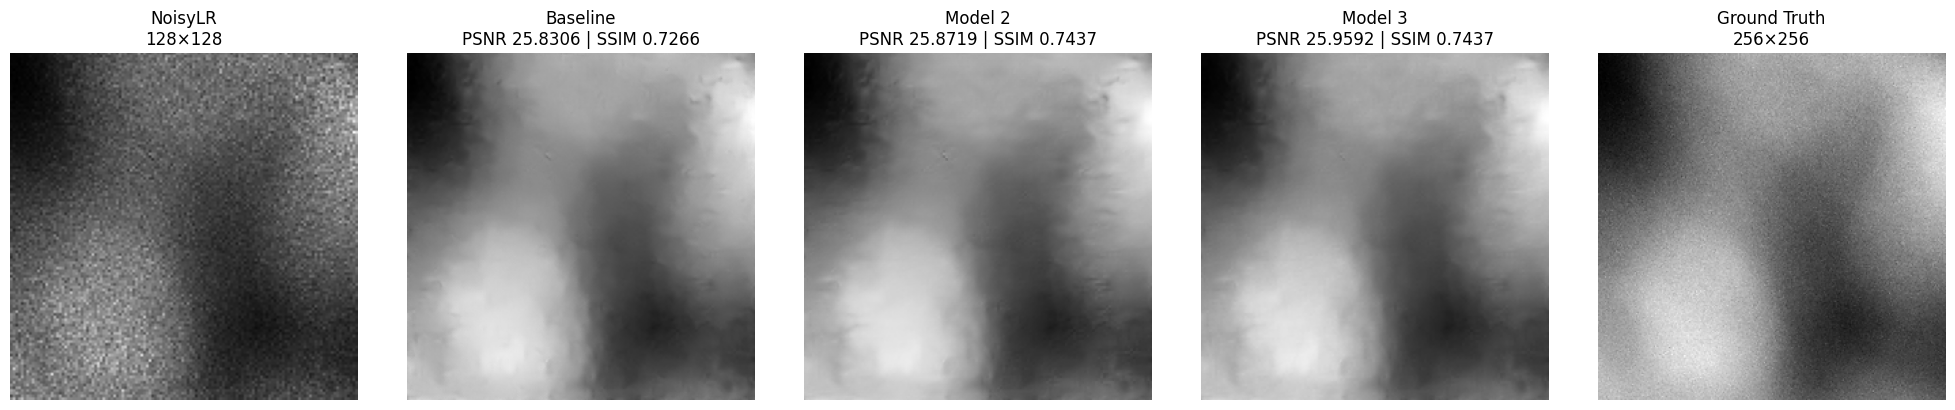

In [ ]:
import torch
import matplotlib.pyplot as plt


# ============================================================
# GET ONE VALIDATION IMAGE
# ============================================================

noisy_batch, gt_batch = next(iter(val_loader))

noisy_batch = noisy_batch.to(
    device,
    dtype=torch.float32
)

gt_batch = gt_batch.to(
    device,
    dtype=torch.float32
)


# ============================================================
# LOAD BASELINE
# ============================================================

baseline_path = (
    "/content/drive/MyDrive/"
    "SEMICON_PROJECT/"
    "best_baseline_model.pth"
)

model.load_state_dict(
    torch.load(
        baseline_path,
        map_location=device
    )
)

model.eval()

with torch.no_grad():
    baseline_output = model(noisy_batch)

baseline_output = torch.clamp(
    baseline_output,
    0.0,
    1.0
)


# ============================================================
# LOAD MODEL 2
# ============================================================

model2_path = (
    "/content/drive/MyDrive/"
    "SEMICON_PROJECT/"
    "best_model2_ssim.pth"
)

model.load_state_dict(
    torch.load(
        model2_path,
        map_location=device
    )
)

model.eval()

with torch.no_grad():
    model2_output = model(noisy_batch)

model2_output = torch.clamp(
    model2_output,
    0.0,
    1.0
)


# ============================================================
# LOAD MODEL 3
# ============================================================

model3_path = (
    "/content/drive/MyDrive/"
    "SEMICON_PROJECT/"
    "best_model3_gradient.pth"
)

model.load_state_dict(
    torch.load(
        model3_path,
        map_location=device
    )
)

model.eval()

with torch.no_grad():
    model3_output = model(noisy_batch)

model3_output = torch.clamp(
    model3_output,
    0.0,
    1.0
)


# ============================================================
# CONVERT FIRST IMAGE TO NUMPY
# ============================================================

noisy_img = noisy_batch[0, 0].cpu().numpy()

baseline_img = (
    baseline_output[0, 0]
    .cpu()
    .numpy()
)

model2_img = (
    model2_output[0, 0]
    .cpu()
    .numpy()
)

model3_img = (
    model3_output[0, 0]
    .cpu()
    .numpy()
)

gt_img = (
    gt_batch[0, 0]
    .cpu()
    .numpy()
)


# ============================================================
# DISPLAY
# ============================================================

plt.figure(figsize=(20, 4))

plt.subplot(1, 5, 1)
plt.imshow(noisy_img, cmap="gray")
plt.title("NoisyLR\n128×128")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(baseline_img, cmap="gray")
plt.title(
    "Baseline\n"
    "PSNR 25.8306 | SSIM 0.7266"
)
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow(model2_img, cmap="gray")
plt.title(
    "Model 2\n"
    "PSNR 25.8719 | SSIM 0.7437"
)
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(model3_img, cmap="gray")
plt.title(
    "Model 3\n"
    "PSNR 25.9592 | SSIM 0.7437"
)
plt.axis("off")

plt.subplot(1, 5, 5)
plt.imshow(gt_img, cmap="gray")
plt.title("Ground Truth\n256×256")
plt.axis("off")

plt.tight_layout()
plt.show()

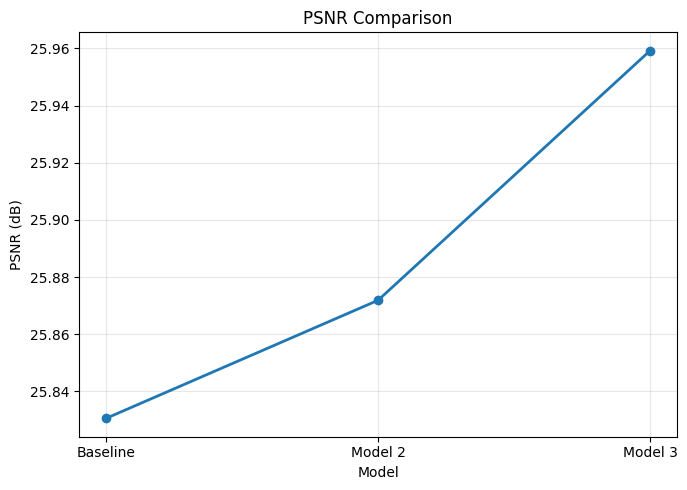

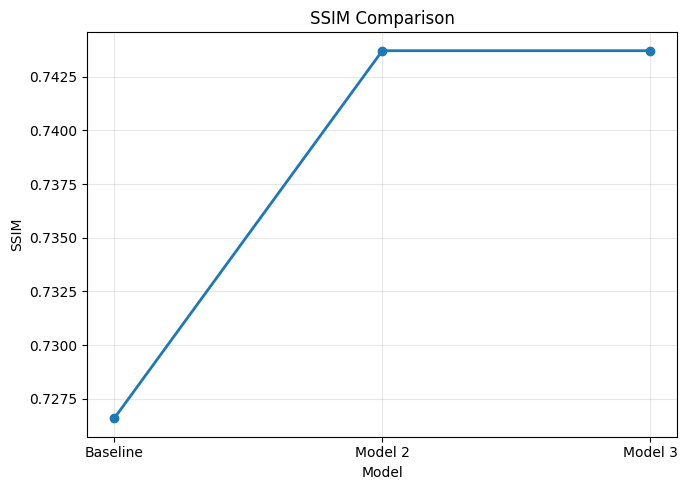

In [ ]:
import matplotlib.pyplot as plt

models = [
    "Baseline",
    "Model 2",
    "Model 3"
]

psnr = [
    25.8306,
    25.8719,
    25.9592
]

ssim = [
    0.7266,
    0.7437,
    0.7437
]

# =========================
# PSNR
# =========================

plt.figure(figsize=(7, 5))

plt.plot(
    models,
    psnr,
    marker="o",
    linewidth=2
)

plt.ylabel("PSNR (dB)")
plt.xlabel("Model")
plt.title("PSNR Comparison")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================
# SSIM
# =========================

plt.figure(figsize=(7, 5))

plt.plot(
    models,
    ssim,
    marker="o",
    linewidth=2
)

plt.ylabel("SSIM")
plt.xlabel("Model")
plt.title("SSIM Comparison")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Model 4

Model 3 + longer training + learning-rate scheduling

In [ ]:
# ============================================================
# MODEL 4 SETUP
# Model 3 + longer training + learning-rate scheduler
# ============================================================

import torch
import torch.nn as nn

# Make sure we're using the GPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ------------------------------------------------------------
# Create fresh model
# ------------------------------------------------------------

model4 = BaselineRestorationNet(
    num_blocks=8,
    channels=64
).to(device)


# ------------------------------------------------------------
# Load BEST Model 3 weights
# ------------------------------------------------------------

model3_path = (
    "/content/drive/MyDrive/"
    "SEMICON_PROJECT/"
    "best_model3_gradient.pth"
)

checkpoint = torch.load(
    model3_path,
    map_location=device
)

model4.load_state_dict(checkpoint)

print("✅ Model 3 weights loaded into Model 4")


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer4 = torch.optim.Adam(
    model4.parameters(),
    lr=1e-4
)


# ------------------------------------------------------------
# Learning-rate scheduler
# ------------------------------------------------------------

scheduler4 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer4,
    mode="min",
    factor=0.5,
    patience=3
)


print("✅ Model 4 ready")
print("Initial learning rate:", optimizer4.param_groups[0]["lr"])

Device: cuda
GPU: Tesla T4
✅ Model 3 weights loaded into Model 4
✅ Model 4 ready
Initial learning rate: 0.0001


In [ ]:
# ============================================================
# MODEL 4 TRAINING
# ============================================================

import time

num_epochs4 = 20

best_val_loss4 = float("inf")

train_losses4 = []
val_losses4 = []


for epoch in range(num_epochs4):

    start_time = time.time()

    # ========================================================
    # TRAIN
    # ========================================================

    model4.train()

    running_train_loss = 0.0

    for noisy, gt in train_loader:

        noisy = noisy.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        gt = gt.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        optimizer4.zero_grad(
            set_to_none=True
        )

        output = model4(noisy)

        output = torch.clamp(
            output,
            0.0,
            1.0
        )

        loss = model3_loss(
            output,
            gt
        )

        loss.backward()

        optimizer4.step()

        running_train_loss += loss.item()


    avg_train_loss = (
        running_train_loss /
        len(train_loader)
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model4.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for noisy, gt in val_loader:

            noisy = noisy.to(
                device,
                dtype=torch.float32,
                non_blocking=True
            )

            gt = gt.to(
                device,
                dtype=torch.float32,
                non_blocking=True
            )

            output = model4(noisy)

            output = torch.clamp(
                output,
                0.0,
                1.0
            )

            loss = model3_loss(
                output,
                gt
            )

            running_val_loss += loss.item()


    avg_val_loss = (
        running_val_loss /
        len(val_loader)
    )


    # ========================================================
    # Scheduler
    # ========================================================

    scheduler4.step(avg_val_loss)

    current_lr = optimizer4.param_groups[0]["lr"]


    train_losses4.append(
        avg_train_loss
    )

    val_losses4.append(
        avg_val_loss
    )


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if avg_val_loss < best_val_loss4:

        best_val_loss4 = avg_val_loss

        torch.save(
            model4.state_dict(),
            "/content/drive/MyDrive/"
            "SEMICON_PROJECT/"
            "best_model4.pth"
        )

        saved = "⭐ BEST"

    else:

        saved = ""


    elapsed = time.time() - start_time


    print(
        f"Epoch [{epoch+1}/{num_epochs4}] "
        f"| Train: {avg_train_loss:.6f} "
        f"| Val: {avg_val_loss:.6f} "
        f"| LR: {current_lr:.2e} "
        f"| Time: {elapsed:.1f}s "
        f"{saved}"
    )


print("\n===== MODEL 4 TRAINING COMPLETE =====")
print(f"Best validation loss: {best_val_loss4:.6f}")
print(
    "Model 4 saved at:"
)
print(
    "/content/drive/MyDrive/"
    "SEMICON_PROJECT/"
    "best_model4.pth"
)

Epoch [1/20] | Train: 0.079466 | Val: 0.081128 | LR: 1.00e-04 | Time: 74.1s ⭐ BEST
Epoch [2/20] | Train: 0.078857 | Val: 0.079715 | LR: 1.00e-04 | Time: 72.6s ⭐ BEST
Epoch [3/20] | Train: 0.078876 | Val: 0.080026 | LR: 1.00e-04 | Time: 72.3s 
Epoch [4/20] | Train: 0.078795 | Val: 0.081821 | LR: 1.00e-04 | Time: 72.5s 
Epoch [5/20] | Train: 0.079023 | Val: 0.079355 | LR: 1.00e-04 | Time: 72.3s ⭐ BEST
Epoch [6/20] | Train: 0.078286 | Val: 0.079530 | LR: 1.00e-04 | Time: 72.4s 
Epoch [7/20] | Train: 0.078254 | Val: 0.078972 | LR: 1.00e-04 | Time: 72.3s ⭐ BEST
Epoch [8/20] | Train: 0.077892 | Val: 0.079001 | LR: 1.00e-04 | Time: 72.2s 
Epoch [9/20] | Train: 0.077828 | Val: 0.078899 | LR: 1.00e-04 | Time: 72.3s ⭐ BEST
Epoch [10/20] | Train: 0.077628 | Val: 0.078503 | LR: 1.00e-04 | Time: 72.4s ⭐ BEST
Epoch [11/20] | Train: 0.077369 | Val: 0.078585 | LR: 1.00e-04 | Time: 72.5s 
Epoch [12/20] | Train: 0.077250 | Val: 0.078285 | LR: 1.00e-04 | Time: 72.5s ⭐ BEST
Epoch [13/20] | Train: 0.077295

In [ ]:
# ==========================================
# LOAD MODEL 4
# ==========================================

import torch

checkpoint_path = "/content/drive/MyDrive/SEMICON_PROJECT/best_model4.pth"

model4 = BaselineRestorationNet(
    num_blocks=8,
    channels=64
).to(device)

model4.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device
    )
)

model4.eval()

print("✅ Model 4 checkpoint loaded")
print("Device:", device)

✅ Model 4 checkpoint loaded
Device: cuda


In [ ]:
from torchmetrics.image import (
    PeakSignalNoiseRatio,
    StructuralSimilarityIndexMeasure
)

psnr_metric = PeakSignalNoiseRatio(
    data_range=1.0
).to(device)

ssim_metric = StructuralSimilarityIndexMeasure(
    data_range=1.0
).to(device)

psnr_metric.reset()
ssim_metric.reset()

with torch.no_grad():

    for noisy_batch, gt_batch in val_loader:

        noisy_batch = noisy_batch.to(device)
        gt_batch = gt_batch.to(device)

        output = model4(noisy_batch)

        # Make sure output is in valid image range
        output = torch.clamp(output, 0.0, 1.0)

        psnr_metric.update(output, gt_batch)
        ssim_metric.update(output, gt_batch)

model4_psnr = psnr_metric.compute().item()
model4_ssim = ssim_metric.compute().item()

print("===== MODEL 4 RESULTS =====")
print(f"PSNR: {model4_psnr:.4f} dB")
print(f"SSIM: {model4_ssim:.4f}")

===== MODEL 4 RESULTS =====
PSNR: 25.6538 dB
SSIM: 0.7541


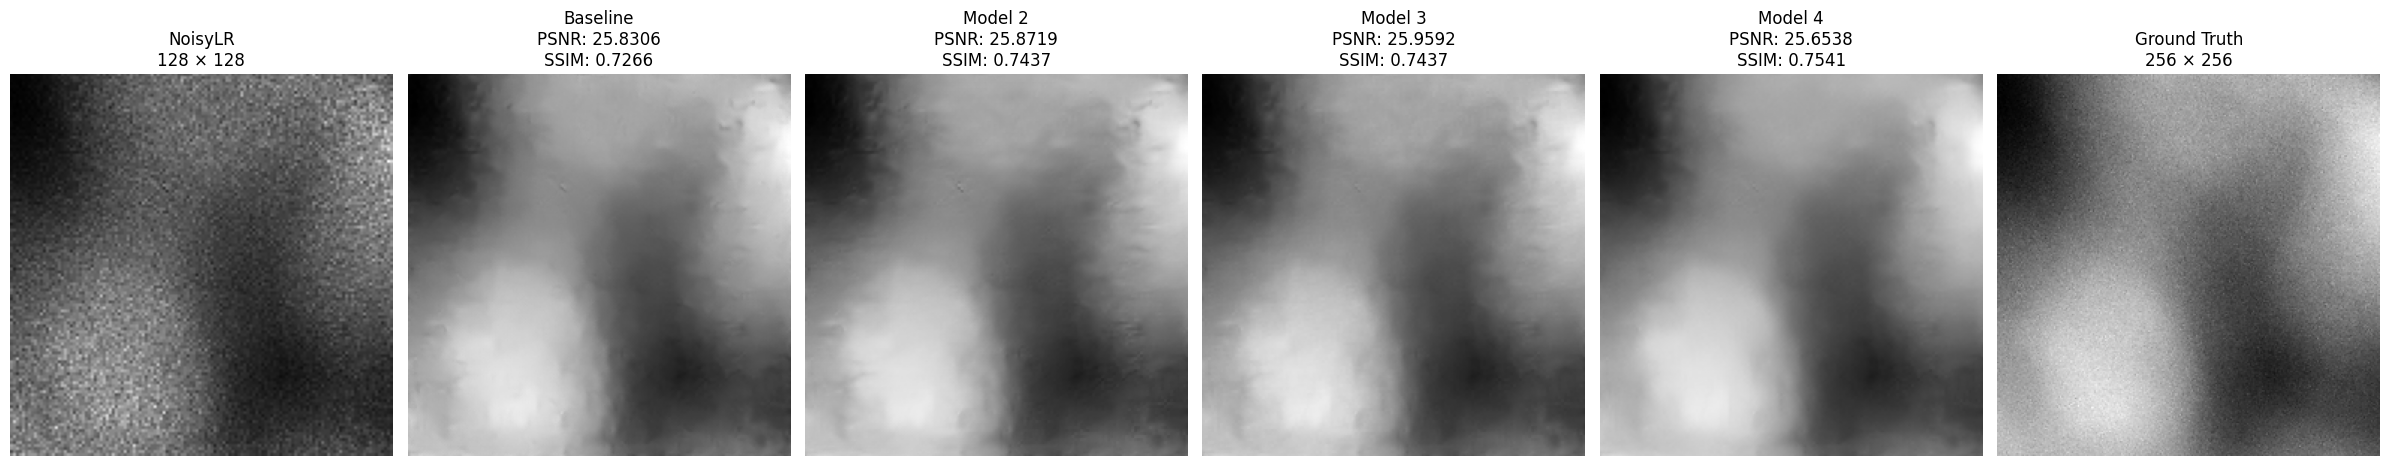

In [ ]:
# ============================================================
# FINAL VISUAL COMPARISON — ALL 4 MODELS
# ============================================================

import torch
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Get ONE validation sample
# ------------------------------------------------------------

noisy_batch, gt_batch = next(iter(val_loader))

noisy_batch = noisy_batch.to(
    device,
    dtype=torch.float32
)

gt_batch = gt_batch.to(
    device,
    dtype=torch.float32
)


# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def get_prediction(model_path):

    temp_model = BaselineRestorationNet(
        num_blocks=8,
        channels=64
    ).to(device)

    temp_model.load_state_dict(
        torch.load(
            model_path,
            map_location=device
        )
    )

    temp_model.eval()

    with torch.no_grad():
        prediction = temp_model(noisy_batch)

    prediction = torch.clamp(
        prediction,
        0.0,
        1.0
    )

    return prediction


# ------------------------------------------------------------
# Load all four models
# ------------------------------------------------------------

baseline_output = get_prediction(
    "/content/drive/MyDrive/SEMICON_PROJECT/best_baseline_model.pth"
)

model2_output = get_prediction(
    "/content/drive/MyDrive/SEMICON_PROJECT/best_model2_ssim.pth"
)

model3_output = get_prediction(
    "/content/drive/MyDrive/SEMICON_PROJECT/best_model3_gradient.pth"
)

model4_output = get_prediction(
    "/content/drive/MyDrive/SEMICON_PROJECT/best_model4.pth"
)


# ------------------------------------------------------------
# Convert FIRST validation image to NumPy
# ------------------------------------------------------------

noisy_img = noisy_batch[0, 0].cpu().numpy()

baseline_img = baseline_output[0, 0].cpu().numpy()

model2_img = model2_output[0, 0].cpu().numpy()

model3_img = model3_output[0, 0].cpu().numpy()

model4_img = model4_output[0, 0].cpu().numpy()

gt_img = gt_batch[0, 0].cpu().numpy()


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

plt.figure(figsize=(24, 5))

plt.subplot(1, 6, 1)
plt.imshow(noisy_img, cmap="gray")
plt.title("NoisyLR\n128 × 128")
plt.axis("off")

plt.subplot(1, 6, 2)
plt.imshow(baseline_img, cmap="gray")
plt.title(
    "Baseline\n"
    "PSNR: 25.8306\n"
    "SSIM: 0.7266"
)
plt.axis("off")

plt.subplot(1, 6, 3)
plt.imshow(model2_img, cmap="gray")
plt.title(
    "Model 2\n"
    "PSNR: 25.8719\n"
    "SSIM: 0.7437"
)
plt.axis("off")

plt.subplot(1, 6, 4)
plt.imshow(model3_img, cmap="gray")
plt.title(
    "Model 3\n"
    "PSNR: 25.9592\n"
    "SSIM: 0.7437"
)
plt.axis("off")

plt.subplot(1, 6, 5)
plt.imshow(model4_img, cmap="gray")
plt.title(
    "Model 4\n"
    "PSNR: 25.6538\n"
    "SSIM: 0.7541"
)
plt.axis("off")

plt.subplot(1, 6, 6)
plt.imshow(gt_img, cmap="gray")
plt.title("Ground Truth\n256 × 256")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================
# Differentiable SSIM
# ============================================

def ssim_loss(pred, target, window_size=11):

    # Local means
    mu_pred = F.avg_pool2d(
        pred,
        window_size,
        stride=1,
        padding=window_size // 2
    )

    mu_target = F.avg_pool2d(
        target,
        window_size,
        stride=1,
        padding=window_size // 2
    )

    # Local variances
    sigma_pred = (
        F.avg_pool2d(
            pred * pred,
            window_size,
            stride=1,
            padding=window_size // 2
        )
        - mu_pred * mu_pred
    )

    sigma_target = (
        F.avg_pool2d(
            target * target,
            window_size,
            stride=1,
            padding=window_size // 2
        )
        - mu_target * mu_target
    )

    # Local covariance
    sigma_pred_target = (
        F.avg_pool2d(
            pred * target,
            window_size,
            stride=1,
            padding=window_size // 2
        )
        - mu_pred * mu_target
    )

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    ssim_map = (
        (2 * mu_pred * mu_target + C1)
        * (2 * sigma_pred_target + C2)
    ) / (
        (mu_pred ** 2 + mu_target ** 2 + C1)
        * (sigma_pred + sigma_target + C2)
    )

    ssim_value = ssim_map.mean()

    return 1.0 - ssim_value


# ============================================
# Gradient loss
# ============================================

def gradient_loss(pred, target):

    pred_x = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    pred_y = pred[:, :, 1:, :] - pred[:, :, :-1, :]

    target_x = target[:, :, :, 1:] - target[:, :, :, :-1]
    target_y = target[:, :, 1:, :] - target[:, :, :-1, :]

    loss_x = F.l1_loss(pred_x, target_x)
    loss_y = F.l1_loss(pred_y, target_y)

    return loss_x + loss_y


# ============================================
# Combined Model 5 loss
# ============================================

def model5_loss(pred, target):

    l1 = F.l1_loss(pred, target)

    ssim = ssim_loss(pred, target)

    grad = gradient_loss(pred, target)

    # Loss weights
    total = (
        0.7 * l1
        + 0.2 * ssim
        + 0.1 * grad
    )

    return total, l1, ssim, grad


print("Model 5 loss defined ✅")

Model 5 loss defined ✅


In [ ]:
# ============================================
# MODEL 5
# ============================================

model5 = BaselineRestorationNet(
    num_blocks=8,
    channels=64
).to(device)

# Load baseline weights
baseline_checkpoint = (
    "/content/drive/MyDrive/SEMICON_PROJECT/"
    "best_baseline_model.pth"
)

model5.load_state_dict(
    torch.load(
        baseline_checkpoint,
        map_location=device,
        weights_only=True
    )
)

print("✅ Baseline weights loaded into Model 5")

# Optimizer
optimizer5 = torch.optim.Adam(
    model5.parameters(),
    lr=1e-4
)

print("Model 5 ready ✅")

✅ Baseline weights loaded into Model 5
Model 5 ready ✅


In [1]:
print("model5 exists:", 'model5' in globals())
print("optimizer exists:", 'optimizer5' in globals())
print("epoch variable exists:", 'epoch' in globals())

model5 exists: False
optimizer exists: False
epoch variable exists: False


In [ ]:
import time
import os

num_epochs = 20

best_val_loss = float("inf")

model5_checkpoint = (
    "/content/drive/MyDrive/SEMICON_PROJECT/"
    "best_model5_combined.pth"
)

for epoch in range(num_epochs):

    start_time = time.time()

    # =========================
    # Training
    # =========================

    model5.train()

    train_loss = 0.0
    train_l1 = 0.0
    train_ssim = 0.0
    train_grad = 0.0

    for noisy, gt in train_loader:

        noisy = noisy.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)

        optimizer5.zero_grad()

        output = model5(noisy)

        loss, l1, ssim, grad = model5_loss(
            output,
            gt
        )

        loss.backward()

        optimizer5.step()

        train_loss += loss.item()
        train_l1 += l1.item()
        train_ssim += ssim.item()
        train_grad += grad.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_train_l1 = train_l1 / len(train_loader)
    avg_train_ssim = train_ssim / len(train_loader)
    avg_train_grad = train_grad / len(train_loader)

    # =========================
    # Validation
    # =========================

    model5.eval()

    val_loss = 0.0
    val_l1 = 0.0
    val_ssim = 0.0
    val_grad = 0.0

    with torch.no_grad():

        for noisy, gt in val_loader:

            noisy = noisy.to(device, non_blocking=True)
            gt = gt.to(device, non_blocking=True)

            output = model5(noisy)

            loss, l1, ssim, grad = model5_loss(
                output,
                gt
            )

            val_loss += loss.item()
            val_l1 += l1.item()
            val_ssim += ssim.item()
            val_grad += grad.item()

    avg_val_loss = val_loss / len(val_loader)
    avg_val_l1 = val_l1 / len(val_loader)
    avg_val_ssim = val_ssim / len(val_loader)
    avg_val_grad = val_grad / len(val_loader)

    # =========================
    # Save best model
    # =========================

    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        torch.save(
            model5.state_dict(),
            model5_checkpoint
        )

        saved = "⭐ BEST"

    else:
        saved = ""

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"| Train: {avg_train_loss:.6f} "
        f"| Val: {avg_val_loss:.6f} "
        f"| L1: {avg_val_l1:.6f} "
        f"| SSIM-L: {avg_val_ssim:.6f} "
        f"| Grad: {avg_val_grad:.6f} "
        f"| Time: {elapsed:.1f}s "
        f"{saved}"
    )

print("\n===== MODEL 5 TRAINING COMPLETE =====")
print(f"Best validation loss: {best_val_loss:.6f}")
print(f"Model 5 saved at:")
print(model5_checkpoint)

Epoch [1/20] | Train: 0.072968 | Val: 0.072372 | L1: 0.033043 | SSIM-L: 0.214699 | Grad: 0.063024 | Time: 72.5s ⭐ BEST
Epoch [2/20] | Train: 0.072259 | Val: 0.072498 | L1: 0.033707 | SSIM-L: 0.213025 | Grad: 0.062979 | Time: 71.8s 
Epoch [3/20] | Train: 0.071868 | Val: 0.072600 | L1: 0.033832 | SSIM-L: 0.213131 | Grad: 0.062918 | Time: 71.9s 
Epoch [4/20] | Train: 0.071946 | Val: 0.072484 | L1: 0.033919 | SSIM-L: 0.212490 | Grad: 0.062423 | Time: 72.1s 
Epoch [5/20] | Train: 0.071594 | Val: 0.071558 | L1: 0.032667 | SSIM-L: 0.212224 | Grad: 0.062461 | Time: 71.7s ⭐ BEST
Epoch [6/20] | Train: 0.071091 | Val: 0.070903 | L1: 0.032703 | SSIM-L: 0.208881 | Grad: 0.062347 | Time: 72.0s ⭐ BEST
Epoch [7/20] | Train: 0.070905 | Val: 0.071128 | L1: 0.032754 | SSIM-L: 0.209884 | Grad: 0.062231 | Time: 71.9s 
Epoch [8/20] | Train: 0.070390 | Val: 0.071284 | L1: 0.032804 | SSIM-L: 0.210482 | Grad: 0.062249 | Time: 71.8s 


In [6]:
print("model5 exists:", 'model5' in globals())
print("optimizer exists:", 'optimizer5' in globals())
print("epoch variable exists:", 'epoch' in globals())

model5 exists: False
optimizer exists: False
epoch variable exists: False
